In [2]:
from shapely.geometry import shape
import json
import pandas as pd
import pandas as pd
import matplotlib.colors as mcolors
import statsmodels.api as sm
import pandas as pd
import numpy as np

In [9]:
import matplotlib.pyplot as plt
import utils.analysis_functions as af
from scipy.signal import detrend

In [4]:
PID_df=pd.read_csv('data/lookup/PID_location_all.csv')
csc_df= pd.read_csv('data/processed/PID_csc_upsampled.csv')
npp_df=pd.read_csv('data/processed/PID_npp.csv')

PID_df, csc_df, npp_df = af.cleaning(PID_df, csc_df, npp_df)

In [5]:
npp_df = npp_df[npp_df['year'] >= 2013]

In [6]:
grouped = npp_df.groupby('PID').apply(lambda x: x.sort_values('year')['Npp'].to_numpy())

In [7]:
def compute_volatility(arr): 
    arr= arr*10
    arr = pd.Series(detrend(arr))
    v=arr.rolling(window=2).std()
    v.dropna(inplace=True)
    v=v.mean()
    return v 

In [10]:

volatility=[]
PID_list=[]
for pid, arr in grouped.items():
    if arr.shape[0] > 5:
        v = af.compute_volatility(arr)
        # returns = np.diff(arr) / arr[:-1]
        # returns = np.abs(returns)
        # v = np.std(returns, ddof=1)
        volatility.append(v)
        PID_list.append(pid)

npp_df1 = pd.DataFrame({'PID': PID_list, 'transformed npp': volatility})

In [12]:
npp_df1.to_csv('volatile_npp.csv')

In [117]:
npp_df1['volatility'].nsmallest(5)

32443    0.0
32458    0.0
32467    0.0
32472    0.0
32474    0.0
Name: volatility, dtype: float64

In [133]:
rows= npp_df1[npp_df1['volatility'] > 2]
rows

,PID,volatility
7417,1_15_1_2364_1,2.693959
7439,1_15_1_2527_1,2.505161
7514,1_15_9_1877_1,2.464739
32428,1_60_10_1007_1,2.526375
32447,1_64_40_65470_1,2.015103
32461,1_64_5_64850_1,2.118458
51866,2_41_19_63618_502,2.033690


In [136]:
rows = npp_df1[(npp_df1['volatility'] < 1) & (npp_df1['volatility'] > 0.5)]
rows

,PID,volatility
1,0_41_27_51502_502,0.559911
2,0_41_27_56058_502,0.533276
5,0_41_27_57279_502,0.585139
6,0_41_27_61522_502,0.590434
8,0_41_27_66356_502,0.619661
...,...,...
122671,9_53_65_92295_501,0.666591
122672,9_53_65_93296_501,0.557528
122673,9_53_65_94513_501,0.662206
122675,9_53_65_97682_501,0.513831


In [127]:
s_rows= npp_df1[npp_df1['volatility'] < 0.03]
s_rows


,PID,volatility
18398,1_32_21_396_420,0.025220
18502,1_32_23_763_420,0.029749
18569,1_32_23_84479_1,0.020270
18924,1_32_3_86068_1,0.013182
19073,1_32_9_91510_1,0.029690
27975,1_4_21_81493_1,0.015994
32443,1_64_40_64917_1,0.000000
32458,1_64_40_66863_1,0.000000
32467,1_64_5_66485_1,0.000000
32472,1_64_60_64210_1,0.000000


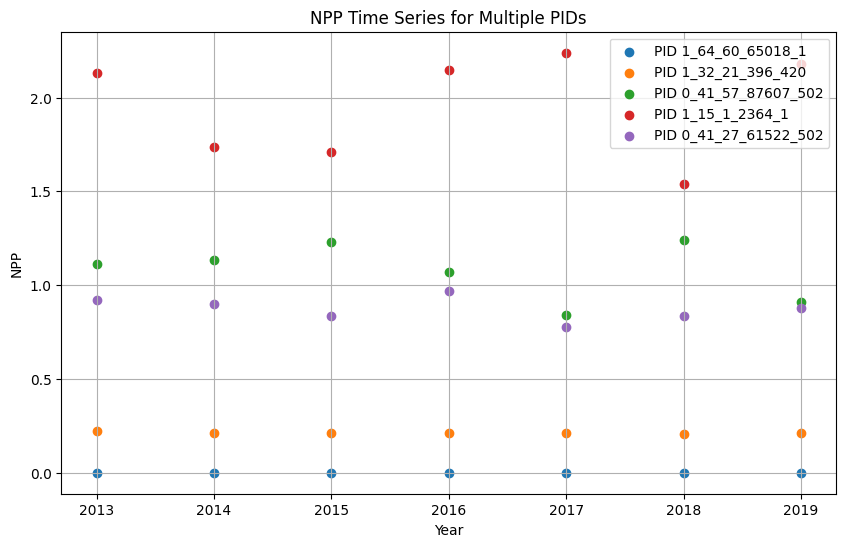

In [137]:
import matplotlib.pyplot as plt

# List of PIDs to plot
pids_to_plot = ['1_64_60_65018_1', '1_32_21_396_420', '0_41_57_87607_502', '1_15_1_2364_1', '0_41_27_61522_502']

plt.figure(figsize=(10,6))

for pid in pids_to_plot:
    # Select rows for this PID
    selected_rows = npp_df[npp_df['PID'] == pid]
    # Scatter or line plot
    plt.scatter(selected_rows['year'], selected_rows['Npp'], marker='o', label=f'PID {pid}')

plt.xlabel('Year')
plt.ylabel('NPP')
plt.title('NPP Time Series for Multiple PIDs')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
x= "volatility"
title='NPP Volatility'

af.histogram(npp_df1, x, title)

NameError: name 'npp_df1' is not defined

In [139]:
total_df = npp_df1.merge(PID_df, on='PID', how='inner')
total_df.dropna(subset=["transformed npp"], inplace=True)

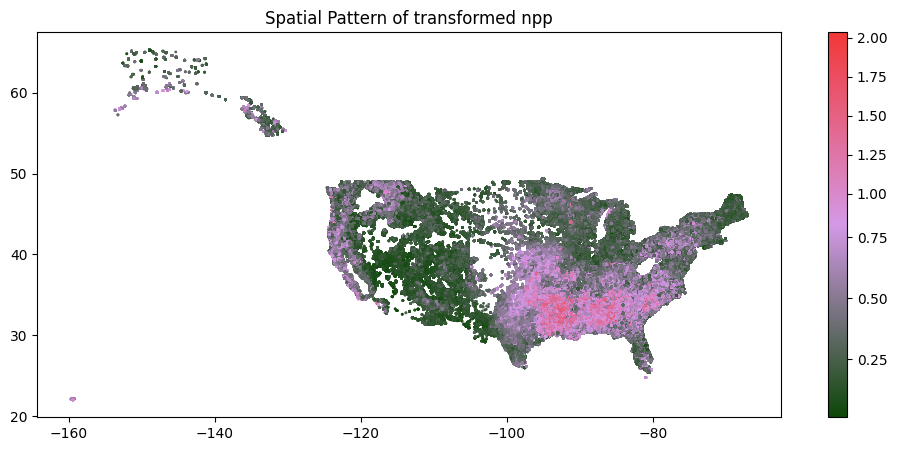

In [148]:
npp_value = 'transformed npp'
title = f"Spatial Pattern of {npp_value}"

cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#0C4708", "#D498E7", "#F23838"]  # pink, zero, positive
)

af.spatial_scatter(total_df["lon"], total_df["lat"], total_df[npp_value], title, cmap, vcenter=0.8)

In [157]:
merged_df = npp_df1.merge(csc_df, on='PID', how='left', suffixes=('_','_orig'))
merged_df = merged_df.drop(columns=[col for col in merged_df.columns if "orig" in col])
merged_df.dropna(subset=['csc', "transformed npp"], inplace=True)


normalized = (merged_df['csc']-min(merged_df['csc']))/(max(merged_df['csc'])-min(merged_df['csc']))
merged_df['Stability metric'] =  - normalized + (merged_df["transformed npp"])
# merged_df["BHAGE"] = merged_df["BHAGE"].fillna("0.0")


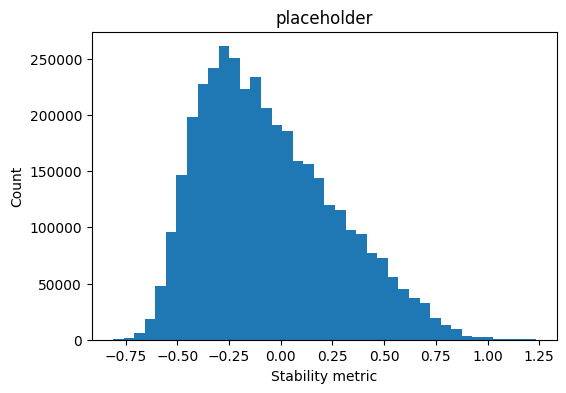

In [158]:
x= "Stability metric"
title='placeholder'

af.histogram(merged_df, x, title)

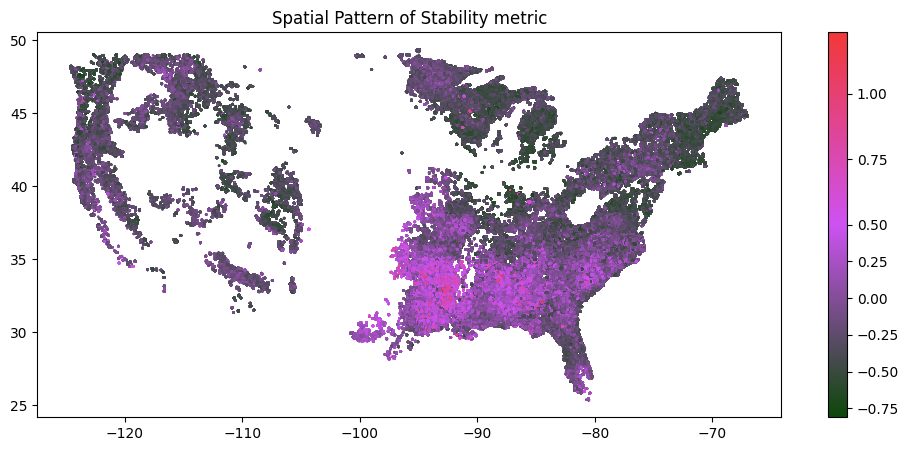

In [ ]:
npp_value = 'Stability metric'
title = f"Spatial Pattern of {npp_value}"

cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#0C4708", "#BE97C9", "#EE0909"]  # pink, zero, positive
)

af.spatial_scatter(merged_df["lon"], merged_df["lat"], merged_df[npp_value], title, cmap, vcenter=0.5)